# Lecture 4/ GV: Portfolio Optimization

## Tasks for today's lecture:
* Portfolio Optimization: objectives, inputs, implementation
* In-sample (IS) vs. Out-of-sample (OOS): look-ahead and danger of overfitting
* GIGO: noise in inputs and errors in portfolio weights, the role of input and output processing
* Constraints: types, roles played and implementation
* Implementation with a simple sample split (no walk-forward for now)

## Topics to cover:
1. **Portfolio Optimization Fundamentals**
   - Objectives: mean-variance optimization, risk-return tradeoff
   - Inputs: expected returns, covariance matrix, risk-free rate
   - Implementation using cvxpy

2. **In-Sample vs. Out-of-Sample Analysis**
   - Look-ahead bias: what it is and how to avoid it
   - Danger of overfitting: why IS performance doesn't guarantee OOS performance
   - Sample split methodology: train/test separation

3. **GIGO (Garbage In, Garbage Out)**
   - Noise in inputs: estimation error in returns and covariances
   - Errors in portfolio weights: impact of input errors on optimization
   - Input processing: shrinkage, regularization, robust estimation
   - Output processing: weight constraints, turnover limits

4. **Constraints in Portfolio Optimization**
   - Types: equality constraints (budget), inequality constraints (bounds, sector limits)
   - Roles: realistic trading, risk management, regulatory compliance
   - Implementation in cvxpy

5. **Simple Sample Split Implementation**
   - Load and prepare data
   - Split into IS (training) and OOS (testing) periods
   - Optimize on IS, evaluate on OOS
   - Compare IS vs OOS performance

**Some useful info:**
* CVXPY documentation: https://www.cvxpy.org/
* Portfolio optimization theory: Markowitz (1952), Black-Litterman model
* Robust optimization: https://www.cvxpy.org/tutorial/advanced/index.html

In [1]:
# after we install all the packages, import all of them for the use in today's lecture!
import platform
my_system = platform.uname()
print(f'My PC node: {my_system.node.lower()}')

# optimization
import cvxpy as cp

# storage and operations
import pandas as pd
import numpy as np
import datetime
from pathlib import Path
import joblib

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistical analysis
from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf, OAS

# set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('dark_background')
sns.set_palette("husl")

print('Packages imported successfully!')

My PC node: mac
Packages imported successfully!


In [2]:
# Configuration and file paths
DATA_FROM_LIMIT = datetime.datetime(2015,1,1)

# we can specify some options depending on your computer
class Options:
    if my_system.node.lower() in ['mac','macbookpro-gv.local']: # GREG'S MACHINE - do not change please
        path = Path('../DataQT2026')
        wrds_name = 'gvfs'
        nasdaqlink_key = 'XXX'
    elif (my_system.node.lower() == 'YOU CAN PUT HERE YOUR NODE'):
        path = Path(r'/.../DataQT2026/')
        wrds_name = 'XXX'
        nasdaqlink_key = 'XXX'
        pass
print('Data Path: ',Options.path)

# some file names
class FileNames:
    fn_crsp = Options.path / 'crsp.parquet'
    fn_stock_features_labels = Options.path / 'stock_features.parquet'
    fn_option_features = Options.path / 'option_features.parquet'
    fn_ff_factors = Options.path / 'ff_factors.parquet'
    fn_sp500comp = Options.path / 'SP500_Index_Constitutes2024.csv'
    fn_universe = Options.path / 'permno_selection.csv'
    
    # Output files for portfolio optimization results
    fn_portfolio_weights = Options.path / 'portfolio_weights.parquet'
    fn_portfolio_performance = Options.path / 'portfolio_performance.parquet'

Data Path:  ../DataQT2026


## Load and prepare data

First, let's load the data we've prepared in previous lectures:
* CRSP stock returns
* Fama-French factors
* Stock features (if available)

In [3]:
'''DEFINE FUNCTIONS TO LOAD THE DATA'''   
def load_ff_crsp():
    """Load Fama-French factors and CRSP stock returns"""
    crsp = pd.read_parquet(FileNames.fn_crsp)
    ff = pd.read_parquet(FileNames.fn_ff_factors)
    return crsp, ff   

# adjust the code to load the features adding the ones from option metrics
def load_features(crsp = True,
                 om = True, 
                  merge = True):
    features_crsp, features_om = pd.DataFrame(), pd.DataFrame()
    if crsp: 
        features_crsp = pd.read_parquet(FileNames.fn_stock_features_labels)
        features_crsp = features_crsp.sort_index()
        pass
    if om:
        features_om = pd.read_parquet(FileNames.fn_option_features)
        features_om = features_om.sort_index()
    if merge:
        res = pd.concat([features_crsp, features_om], axis = 1).sort_index()
    else:
        res = (features_crsp, features_om)
    return res

# Load the data
crsp, ff = load_ff_crsp()
features_crsp = load_features()

print(f"CRSP data shape: {crsp.shape}")
print(f"FF factors shape: {ff.shape}")
if not features_crsp.empty:
    print(f"Features shape: {features_crsp.shape}")

CRSP data shape: (1768460, 12)
FF factors shape: (3018, 7)
Features shape: (1776703, 20)


## Helper Functions for Portfolio Optimization

Let's create helper functions for:
1. Preparing returns data (pivot to wide format)
2. Computing expected returns and covariance matrix
3. Sample splitting (IS/OOS)
4. Portfolio optimization with cvxpy
5. Performance evaluation

For expected returns we will for now use simple mean returns, while for the covariance matrix we implement three methods: sample covariance, Ledoit-Wolf shrinakge, and OAS shrinkage.

Ledoit-Wolf shrinkage is a method for estimating covariance matrices in high-dimensional data, where the sample covariance $  \hat{S}  $ is shrunk toward a target matrix $\hat{F}  $ (typically $\frac{Trace(\hat{S})}{p} I  $, with $  p  $ features) to improve stability and reduce estimation error. The shrunk estimator is $  \hat{\Sigma}^{\text{LW}} = (1 - \hat{\rho}) \hat{S} + \hat{\rho} \hat{F}  $, with the optimal shrinkage intensity $  \hat{\rho}  $ derived analytically to minimize asymptotic mean squared error under normality assumptions. It's particularly useful when samples $  n  $ are comparable to or smaller than $  p  $, and serves as a foundation for later methods like OAS.

The Oracle Approximating Shrinkage (OAS) estimator is a shrinkage method for covariance matrix estimation, particularly useful in high-dimensional settings where the number of features (p) is large relative to the number of samples (n), leading to unstable or ill-conditioned sample covariance matrices. It improves upon earlier approaches like Ledoit-Wolf shrinkage by providing a closed-form approximation to the optimal shrinkage intensity under the assumption of Gaussian-distributed data, resulting in better convergence and lower mean squared error for small sample sizes.

In [4]:
def prepare_returns_data(crsp_df, date_col='date', permno_col='permno', ret_col='ret', 
                         min_obs=60, min_stocks=20):
    """
    Prepare returns data in wide format (dates x stocks)
    
    Parameters:
    -----------
    crsp_df : DataFrame
        CRSP data with columns: date, permno, ret
    date_col : str
        Name of date column
    permno_col : str
        Name of stock identifier column
    ret_col : str
        Name of returns column
    min_obs : int
        Minimum number of observations required per stock
    min_stocks : int
        Minimum number of stocks required per date
    
    Returns:
    --------
    returns_wide : DataFrame
        Wide format returns (dates x stocks)
    """
    # Convert date to datetime if needed
    crsp_df = crsp_df.copy()
    crsp_df[date_col] = pd.to_datetime(crsp_df[date_col])
    
    # Pivot to wide format
    returns_wide = crsp_df.pivot_table(
        index=date_col, 
        columns=permno_col, 
        values=ret_col
    )
    
    # Filter stocks with sufficient observations
    stock_counts = returns_wide.count()
    valid_stocks = stock_counts[stock_counts >= min_obs].index
    returns_wide = returns_wide[valid_stocks]
    
    # Filter dates with sufficient stocks
    date_counts = returns_wide.count(axis=1)
    valid_dates = date_counts[date_counts >= min_stocks].index
    returns_wide = returns_wide.loc[valid_dates]
    
    # Sort by date
    returns_wide = returns_wide.sort_index()
    
    print(f"Returns matrix shape: {returns_wide.shape}")
    print(f"Date range: {returns_wide.index.min()} to {returns_wide.index.max()}")
    print(f"Number of stocks: {len(returns_wide.columns)}")
    
    return returns_wide

In [5]:
def compute_moments(returns_df, 
                    method='sample', shrinkage=None,
                    mean_shrinkage=None, mean_shrink_alpha=0.5, mean_shrink_target='zero'):
    """
    Compute expected returns and covariance matrix.

    Parameters:
    -----------
    returns_df : DataFrame
        Returns in wide format (dates x stocks)
    method : str
        Method for expected returns: 'sample', 'zero', 'equal'
    shrinkage : str or None
        Shrinkage method for covariance: None, 'ledoit-wolf', 'oas'
    mean_shrinkage : str or None
        If not None, shrink sample means toward a target.
        Options:
          - 'ridge': convex combination of sample mean and a target mean
    mean_shrink_alpha : float in [0,1]
        Shrinkage intensity. 0 -> no shrinkage (use sample mean), 1 -> full target.
    mean_shrink_target : str
        Target for mean shrinkage:
          - 'zero'  : shrink toward 0 (no alpha)
          - 'grand' : shrink toward the cross-sectional grand mean

    Returns:
    --------
    mu : array (annualized)
        Expected returns vector
    Sigma : array (annualized)
        Covariance matrix
    """
    # Convert to numpy array and ensure numeric types
    returns_array = returns_df.to_numpy(dtype=float, na_value=np.nan)

    # -------- Expected returns (daily) --------
    if method == 'sample':
        mu = np.nanmean(returns_array, axis=0)
        mu = np.where(np.isnan(mu), 0, mu)
        mu = np.where(np.isinf(mu), 0, mu)

        # Mean shrinkage (input regularization)
        if mean_shrinkage is not None:
            a = float(mean_shrink_alpha)
            a = min(max(a, 0.0), 1.0)

            if mean_shrink_target == 'zero':
                target = np.zeros_like(mu)
            elif mean_shrink_target == 'grand':
                grand = np.nanmean(mu)
                if np.isnan(grand) or np.isinf(grand):
                    grand = 0.0
                target = np.full_like(mu, grand)
            else:
                raise ValueError(f"Unknown mean_shrink_target: {mean_shrink_target}")

            # convex combination: (1-a)*sample + a*target
            mu = (1 - a) * mu + a * target

    elif method == 'zero':
        mu = np.zeros(returns_array.shape[1])
    elif method == 'equal':
        mu = np.ones(returns_array.shape[1]) / returns_array.shape[1]
    else:
        raise ValueError(f"Unknown method: {method}")

    # -------- Covariance (daily) --------
    if shrinkage is None:
        Sigma = returns_df.cov().values
    elif shrinkage == 'ledoit-wolf':
        complete_rows = ~np.isnan(returns_array).all(axis=1)
        returns_array_clean = returns_array[complete_rows, :]

        if returns_array_clean.shape[0] < 2:
            Sigma = returns_df.cov().values
        else:
            returns_array_filled = returns_array_clean.copy()
            for i in range(returns_array_filled.shape[1]):
                col_mean = np.nanmean(returns_array_filled[:, i])
                if np.isnan(col_mean):
                    returns_array_filled[:, i] = 0
                else:
                    returns_array_filled[np.isnan(returns_array_filled[:, i]), i] = col_mean

            lw = LedoitWolf()
            Sigma = lw.fit(returns_array_filled).covariance_
    elif shrinkage == 'oas':
        complete_rows = ~np.isnan(returns_array).all(axis=1)
        returns_array_clean = returns_array[complete_rows, :]

        if returns_array_clean.shape[0] < 2:
            Sigma = returns_df.cov().values
        else:
            returns_array_filled = returns_array_clean.copy()
            for i in range(returns_array_filled.shape[1]):
                col_mean = np.nanmean(returns_array_filled[:, i])
                if np.isnan(col_mean):
                    returns_array_filled[:, i] = 0
                else:
                    returns_array_filled[np.isnan(returns_array_filled[:, i]), i] = col_mean

            oas = OAS()
            Sigma = oas.fit(returns_array_filled).covariance_
    else:
        raise ValueError(f"Unknown shrinkage method: {shrinkage}")

    # -------- Clean up Sigma --------
    if np.any(~np.isfinite(Sigma)):
        nan_mask = ~np.isfinite(Sigma)
        Sigma[nan_mask] = 0
        diag_nan = ~np.isfinite(np.diag(Sigma))
        if np.any(diag_nan):
            mean_diag = np.nanmean(np.diag(Sigma))
            if np.isnan(mean_diag) or mean_diag <= 0:
                mean_diag = 0.01
            np.fill_diagonal(Sigma, np.where(diag_nan, mean_diag, np.diag(Sigma)))

    Sigma = (Sigma + Sigma.T) / 2

    if np.all(np.isfinite(Sigma)):
        eigenvals = np.linalg.eigvals(Sigma)
        if np.any(eigenvals < -1e-8):
            min_eigenval = np.min(eigenvals)
            if min_eigenval < 0:
                Sigma = Sigma - min_eigenval * np.eye(Sigma.shape[0]) + 1e-8 * np.eye(Sigma.shape[0])
    else:
        np.fill_diagonal(Sigma, np.diag(Sigma) + 1e-6)

    # -------- Annualize --------
    mu = mu * 252
    Sigma = Sigma * 252

    if np.any(~np.isfinite(mu)):
        print(f"Warning: Found {np.sum(~np.isfinite(mu))} non-finite values in expected returns. Replacing with 0.")
        mu = np.where(np.isfinite(mu), mu, 0)

    if np.any(~np.isfinite(Sigma)):
        print(f"Warning: Found {np.sum(~np.isfinite(Sigma))} non-finite values in covariance matrix. Cleaning...")
        Sigma = np.where(np.isfinite(Sigma), Sigma, 0)
        np.fill_diagonal(Sigma, np.maximum(np.diag(Sigma), 1e-8))
        Sigma = (Sigma + Sigma.T) / 2

    return mu, Sigma


In [6]:
def split_sample(returns_df, split_date, is_label='IS', oos_label='OOS'):
    """
    Split returns data into in-sample (IS) and out-of-sample (OOS) periods
    
    Parameters:
    -----------
    returns_df : DataFrame
        Returns in wide format (dates x stocks)
    split_date : datetime or str
        Date to split the sample
    is_label : str
        Label for in-sample period
    oos_label : str
        Label for out-of-sample period
    
    Returns:
    --------
    is_returns : DataFrame
        In-sample returns
    oos_returns : DataFrame
        Out-of-sample returns
    """
    split_date = pd.to_datetime(split_date)
    
    is_returns = returns_df[returns_df.index < split_date].copy()
    oos_returns = returns_df[returns_df.index >= split_date].copy()
    
    print(f"In-sample period: {is_returns.index.min()} to {is_returns.index.max()}")
    print(f"In-sample shape: {is_returns.shape}")
    print(f"Out-of-sample period: {oos_returns.index.min()} to {oos_returns.index.max()}")
    print(f"Out-of-sample shape: {oos_returns.shape}")
    
    return is_returns, oos_returns

Here we have a function that runs portfolio optimizaiton with different objectives. You can use it as a wrapper for simpler or more complex portfolio construction methods later on, and also implement additional constraints.  

In [7]:
def optimize_portfolio(mu, Sigma, 
                        risk_free_rate=0.0, 
                        objective='mean_variance', 
                        risk_aversion=1.0, target_return=None, target_vol=None,
                        constraints=None, zero_cost=False, verbose=True):
    """
    Optimize portfolio using cvxpy
    
    Parameters:
    -----------
    mu : array
        Expected returns vector (n,)
    Sigma : array
        Covariance matrix (n, n)
    risk_free_rate : float
        Risk-free rate (annualized)
    objective : str
        Objective function: 'mean_variance', 'max_sharpe', 'min_variance', 'max_return'
    risk_aversion : float
        Risk aversion parameter (for mean-variance)
    target_return : float or None
        Target return (for min variance with return constraint)
    target_vol : float or None
        Target volatility (for max return with vol constraint)
    constraints : dict or None
        Additional constraints: 
        - 'long_only': bool (weights >= 0)
        - 'max_weight': float (max individual weight)
        - 'min_weight': float (min individual weight)
        - 'sector_limits': dict (sector: max_weight)
    zero_cost : bool
        If False (default): weights sum to 1 (fully invested)
        If True: weights sum to 0 (dollar-neutral), with long weights summing to 1 and short weights summing to -1
    verbose : bool
        Print optimization details
    
    Returns:
    --------
    weights : array
        Optimal portfolio weights (n,)
    portfolio_return : float
        Expected portfolio return
    portfolio_vol : float
        Portfolio volatility
    sharpe_ratio : float
        Sharpe ratio
    """
    n = len(mu)
    
    # Decision variable: portfolio weights
    w = cp.Variable(n)
    
    # Initialize max_sharpe solution storage (for SOCP trick)
    _max_sharpe_solution = None
    
    # Budget constraint based on zero_cost parameter
    constraint_list = []
    if zero_cost:
        # Dollar-neutral: net exposure is zero
        # Long positions sum to 1, short positions sum to -1
        # Use auxiliary variables for long and short positions
        w_long = cp.Variable(n)  # Long positions (non-negative)
        w_short = cp.Variable(n)  # Short positions (non-negative, will be negated)
        
        # w = w_long - w_short (long minus short)
        constraint_list.append(w == w_long - w_short)
        constraint_list.append(w_long >= 0)
        constraint_list.append(w_short >= 0)
        
        # Net exposure is zero
        constraint_list.append(cp.sum(w) == 0)
        # Long positions sum to 1
        constraint_list.append(cp.sum(w_long) == 1)
        # Short positions sum to 1 (which means w_short values sum to 1, so -w_short sums to -1)
        constraint_list.append(cp.sum(w_short) == 1)
    else:
        # Fully invested: weights sum to 1
        constraint_list.append(cp.sum(w) == 1)
    
    # Add constraints
    if constraints is None:
        constraints = {}
    
    if constraints.get('long_only', False):
        constraint_list.append(w >= 0)
    
    if 'max_weight' in constraints:
        constraint_list.append(w <= constraints['max_weight'])
    
    if 'min_weight' in constraints:
        constraint_list.append(w >= constraints['min_weight'])
    
    # Objective function
    if objective == 'mean_variance':
        # Maximize: mu^T w - lambda * w^T Sigma w
        objective_func = cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, Sigma))
        
    elif objective == 'max_sharpe':
        # Maximize Sharpe ratio: (mu^T w - rf) / sqrt(w^T Sigma w)
        # Use SOCP-friendly trick: minimize variance subject to excess return >= 1
        # This is equivalent to maximizing Sharpe (same direction on efficient frontier)
        # After solving, we rescale weights to satisfy original constraints
        
        excess_returns = mu - risk_free_rate
        
        # Rebuild constraints from scratch (don't use constraint_list to avoid variable conflicts)
        # We'll add all constraints except the budget constraint, which we'll handle via rescaling
        temp_constraints = []
        
        # For zero_cost: use sum of positive = sum of negative (unnormalized)
        if zero_cost:
            # Use auxiliary variables for long and short
            w_long_temp = cp.Variable(n)
            w_short_temp = cp.Variable(n)
            temp_constraints.append(w == w_long_temp - w_short_temp)
            temp_constraints.append(w_long_temp >= 0)
            temp_constraints.append(w_short_temp >= 0)
            # Sum of positive weights = sum of negative weights (in absolute value)
            # This ensures dollar-neutrality without fixing the scale
            temp_constraints.append(cp.sum(w_long_temp) == cp.sum(w_short_temp))
        # For non-zero_cost: no budget constraint (will rescale to sum=1 later)
        
        # Add other constraints from constraints dict
        if constraints is not None:
            if constraints.get('long_only', False):
                temp_constraints.append(w >= 0)
            if 'max_weight' in constraints:
                temp_constraints.append(w <= constraints['max_weight'])
            if 'min_weight' in constraints:
                temp_constraints.append(w >= constraints['min_weight'])
        
        # SOCP-friendly formulation: minimize variance subject to excess return >= 1
        temp_constraints.append(excess_returns @ w >= 1.0)
        objective_func = cp.Minimize(cp.quad_form(w, Sigma))
        
        # Solve the unnormalized problem
        temp_problem = cp.Problem(objective_func, temp_constraints)
        temp_problem.solve(verbose=verbose)
        
        if temp_problem.status not in ['optimal', 'optimal_inaccurate']:
            raise ValueError(f"Max Sharpe optimization failed with status: {temp_problem.status}")
        
        # Get unnormalized weights
        w_unnormalized = w.value
        
        if w_unnormalized is None:
            raise ValueError("Max Sharpe optimization returned None weights")
        
        # Rescale weights to satisfy original constraints
        if zero_cost:
            # For zero_cost: rescale so sum of positive = sum of negative = 1
            w_pos = np.maximum(w_unnormalized, 0)
            w_neg = np.minimum(w_unnormalized, 0)
            sum_pos = np.sum(w_pos)
            sum_neg = abs(np.sum(w_neg))
            
            if sum_pos > 1e-10:
                w_pos_scaled = w_pos / sum_pos
            else:
                w_pos_scaled = w_pos
            
            if sum_neg > 1e-10:
                w_neg_scaled = w_neg / sum_neg
            else:
                w_neg_scaled = w_neg
            
            weights = w_pos_scaled + w_neg_scaled
        else:
            # For non-zero_cost: rescale so weights sum to 1
            sum_weights = np.sum(w_unnormalized)
            if abs(sum_weights) > 1e-10:
                weights = w_unnormalized / sum_weights
            else:
                weights = w_unnormalized
        
        # Store solution to return (skip the normal solve step)
        _max_sharpe_solution = {
            'weights': weights,
            'status': temp_problem.status
        }
        
    elif objective == 'min_variance':
        # Minimize variance: w^T Sigma w
        objective_func = cp.Minimize(cp.quad_form(w, Sigma))
        if target_return is not None:
            constraint_list.append(mu @ w >= target_return)
            
    elif objective == 'max_return':
        # Maximize return: mu^T w
        objective_func = cp.Maximize(mu @ w)
        if target_vol is not None:
            constraint_list.append(cp.quad_form(w, Sigma) <= target_vol**2)
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    # Solve optimization problem (unless we already have the solution from max_sharpe SOCP trick)
    if objective == 'max_sharpe' and _max_sharpe_solution is not None:
        # Use the solution from SOCP approach
        weights = _max_sharpe_solution['weights']
        problem_status = _max_sharpe_solution['status']
        # Compute portfolio statistics from rescaled weights
        portfolio_return = mu @ weights
        portfolio_vol = np.sqrt(weights @ Sigma @ weights)
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
    else:
        # Solve the optimization problem normally
        problem = cp.Problem(objective_func, constraint_list)
        problem.solve(verbose=verbose)
        
        if problem.status not in ['optimal', 'optimal_inaccurate']:
            raise ValueError(f"Optimization failed with status: {problem.status}")
        
        weights = w.value
        
        # Compute portfolio statistics
        portfolio_return = mu @ weights
        portfolio_vol = np.sqrt(weights @ Sigma @ weights)
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
        problem_status = problem.status
    
    if verbose:
        if objective == 'max_sharpe' and _max_sharpe_solution is not None:
            print(f"Optimization status: {problem_status} (SOCP max Sharpe)")
            print(f"Method: Minimize variance subject to excess return >= 1, then rescale")
        else:
            print(f"Optimization status: {problem_status}")
        print(f"Portfolio return: {portfolio_return:.4f}")
        print(f"Portfolio volatility: {portfolio_vol:.4f}")
        print(f"Sharpe ratio: {sharpe_ratio:.4f}")
        print(f"Number of positions: {(np.abs(weights) > 1e-6).sum()}")
        print(f"Max weight: {weights.max():.4f}")
        print(f"Min weight: {weights.min():.4f}")
    
    return weights, portfolio_return, portfolio_vol, sharpe_ratio

In [8]:
def optimize_portfolio_minimize(mu, Sigma, 
                                risk_free_rate=0.0, 
                                objective='mean_variance', 
                                risk_aversion=1.0, target_return=None, target_vol=None,
                                constraints=None, zero_cost=False, verbose=True):
    """
    Optimize portfolio using scipy.optimize.minimize
    
    This function provides the same functionality as optimize_portfolio but uses
    scipy's minimize solver instead of cvxpy. Useful for comparison and when
    cvxpy is not available.
    
    Parameters:
    -----------
    mu : array
        Expected returns vector (n,)
    Sigma : array
        Covariance matrix (n, n)
    risk_free_rate : float
        Risk-free rate (annualized)
    objective : str
        Objective function: 'mean_variance', 'max_sharpe', 'min_variance', 'max_return'
    risk_aversion : float
        Risk aversion parameter (for mean-variance)
    target_return : float or None
        Target return (for min variance with return constraint)
    target_vol : float or None
        Target volatility (for max return with vol constraint)
    constraints : dict or None
        Additional constraints: 
        - 'long_only': bool (weights >= 0)
        - 'max_weight': float (max individual weight)
        - 'min_weight': float (min individual weight)
        - 'sector_limits': dict (sector: max_weight)
    zero_cost : bool
        If False (default): weights sum to 1 (fully invested)
        If True: weights sum to 0 (dollar-neutral), with long weights summing to 1 and short weights summing to -1
    verbose : bool
        Print optimization details
    
    Returns:
    --------
    weights : array
        Optimal portfolio weights (n,)
    portfolio_return : float
        Expected portfolio return
    portfolio_vol : float
        Portfolio volatility
    sharpe_ratio : float
        Sharpe ratio
    """
    n = len(mu)
    
    # Initialize bounds
    if constraints is None:
        constraints = {}
    
    # Set up bounds for individual weights
    if constraints.get('long_only', False):
        # Long-only: weights >= 0
        bounds = [(0, None) for _ in range(n)]
    else:
        # Allow shorting: no bounds (or very wide bounds)
        bounds = [(None, None) for _ in range(n)]
    
    # Apply min/max weight constraints
    if 'min_weight' in constraints:
        min_w = constraints['min_weight']
        bounds = [(max(b[0] if b[0] is not None else -np.inf, min_w), b[1]) for b in bounds]
    
    if 'max_weight' in constraints:
        max_w = constraints['max_weight']
        bounds = [(b[0], min(b[1] if b[1] is not None else np.inf, max_w)) for b in bounds]
    
    # Set up constraints list for scipy
    scipy_constraints = []
    
    # Budget constraint
    if zero_cost:
        # Dollar-neutral: sum(w) = 0, and sum of absolute weights = 2
        # This ensures long positions sum to 1 and short positions sum to -1
        def budget_constraint_zero(w):
            """Constraint: sum of weights = 0"""
            return np.sum(w)
        
        def abs_weight_constraint(w):
            """Constraint: sum of absolute weights = 2"""
            return np.sum(np.abs(w)) - 2.0
        
        scipy_constraints.append({
            'type': 'eq',
            'fun': budget_constraint_zero
        })
        scipy_constraints.append({
            'type': 'eq',
            'fun': abs_weight_constraint
        })
    else:
        # Fully invested: sum(w) = 1
        def budget_constraint(w):
            """Constraint: sum of weights = 1"""
            return np.sum(w) - 1.0
        
        scipy_constraints.append({
            'type': 'eq',
            'fun': budget_constraint
        })
    
    # Target return constraint (for min_variance with return target)
    if target_return is not None:
        def return_constraint(w):
            """Constraint: expected return >= target_return"""
            return mu @ w - target_return
        
        scipy_constraints.append({
            'type': 'ineq',
            'fun': return_constraint
        })
    
    # Target volatility constraint (for max_return with vol target)
    if target_vol is not None:
        def vol_constraint(w):
            """Constraint: volatility <= target_vol"""
            portfolio_var = w @ Sigma @ w
            return target_vol**2 - portfolio_var
        
        scipy_constraints.append({
            'type': 'ineq',
            'fun': vol_constraint
        })
    
    # Initial guess: equal weights (normalized)
    if zero_cost:
        # For zero_cost: start with equal long/short positions
        # Half positive (sum to 1), half negative (sum to -1)
        w0 = np.ones(n) / n
        # Make half negative to satisfy sum = 0 and sum(abs) = 2
        mid = n // 2
        w0[mid:] = -w0[mid:]
        # Ensure sum(abs) = 2 exactly
        w0 = w0 * (2.0 / np.sum(np.abs(w0)))
    else:
        w0 = np.ones(n) / n
    
    # Define objective functions
    if objective == 'mean_variance':
        # Maximize: mu^T w - lambda * w^T Sigma w
        # Minimize: -(mu^T w - lambda * w^T Sigma w)
        def objective_func(w):
            portfolio_return = mu @ w
            portfolio_var = w @ Sigma @ w
            return -(portfolio_return - risk_aversion * portfolio_var)
    
    elif objective == 'max_sharpe':
        # Maximize Sharpe: (mu^T w - rf) / sqrt(w^T Sigma w)
        # Minimize: -Sharpe ratio = -(mu^T w - rf) / sqrt(w^T Sigma w)
        # Add small epsilon to avoid division by zero
        def objective_func(w):
            excess_return = (mu - risk_free_rate) @ w
            portfolio_vol = np.sqrt(w @ Sigma @ w)
            if portfolio_vol < 1e-10:
                return 1e10  # Penalty for zero volatility
            return -excess_return / portfolio_vol
    
    elif objective == 'min_variance':
        # Minimize variance: w^T Sigma w
        def objective_func(w):
            return w @ Sigma @ w
    
    elif objective == 'max_return':
        # Maximize return: mu^T w
        # Minimize: -mu^T w
        def objective_func(w):
            return -(mu @ w)
    
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    # Solve optimization problem
    result = minimize(
        objective_func,
        w0,
        method='SLSQP',  # Sequential Least Squares Programming - handles bounds and constraints
        bounds=bounds,
        constraints=scipy_constraints,
        options={'maxiter': 1000, 'ftol': 1e-9}
    )
    
    if not result.success:
        raise ValueError(f"Optimization failed with status: {result.status}, message: {result.message}")
    
    weights = result.x
    
    # Compute portfolio statistics
    portfolio_return = mu @ weights
    portfolio_vol = np.sqrt(weights @ Sigma @ weights)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else 0
    
    if verbose:
        print(f"Optimization status: {result.status} (scipy.optimize.minimize)")
        print(f"Method: {result.method}")
        print(f"Portfolio return: {portfolio_return:.4f}")
        print(f"Portfolio volatility: {portfolio_vol:.4f}")
        print(f"Sharpe ratio: {sharpe_ratio:.4f}")
        print(f"Number of positions: {(np.abs(weights) > 1e-6).sum()}")
        print(f"Max weight: {weights.max():.4f}")
        print(f"Min weight: {weights.min():.4f}")
        print(f"Sum of weights: {weights.sum():.6f}")
    
    return weights, portfolio_return, portfolio_vol, sharpe_ratio

In [9]:
def evaluate_portfolio(weights, returns_df, risk_free_rate=0.0):
    """
    Evaluate portfolio performance on out-of-sample returns
    
    Parameters:
    -----------
    weights : array
        Portfolio weights (n,)
    returns_df : DataFrame
        Out-of-sample returns (dates x stocks)
    risk_free_rate : float
        Risk-free rate (annualized)
    
    Returns:
    --------
    results : dict
        Dictionary with performance metrics
    portfolio_returns : Series
        Time series of portfolio returns
    """
    # Ensure weights align with returns columns
    # Convert to numpy array and handle NaN
    returns_array = returns_df.to_numpy(dtype=float, na_value=np.nan)
    
    # Ensure weights and returns are aligned
    if len(weights) != returns_array.shape[1]:
        raise ValueError(f"Weight length ({len(weights)}) doesn't match returns columns ({returns_array.shape[1]})")
    
    # Compute portfolio returns: handle NaN by computing weighted sum only for valid observations
    # For each period, compute portfolio return using only stocks with valid (non-NaN) returns
    # CRITICAL FIX: For portfolios with short positions, we should NOT normalize by sum of valid weights
    # Instead, compute portfolio return directly as weighted sum (weights already sum to 1 overall)
    portfolio_returns = np.zeros(returns_array.shape[0])
    for t in range(returns_array.shape[0]):
        period_returns = returns_array[t, :]
        valid_mask = ~np.isnan(period_returns)
        if valid_mask.sum() > 0:
            # Only use stocks with valid returns for this period
            valid_weights = weights[valid_mask]
            valid_returns = period_returns[valid_mask]
            # For portfolios with short positions, compute return directly without normalization
            # The weights already sum to 1 (long - short = 1), so we use them as-is
            # Only normalize if we want to maintain the same gross exposure when some stocks are missing
            # But for evaluation purposes, we compute the actual portfolio return
            portfolio_returns[t] = np.sum(valid_returns * valid_weights)
        else:
            portfolio_returns[t] = np.nan
    
    # Convert to Series with dates
    portfolio_returns = pd.Series(portfolio_returns, index=returns_df.index)
    
    # Drop NaN values for statistics computation
    portfolio_returns_clean = portfolio_returns.dropna()
    
    if len(portfolio_returns_clean) == 0:
        # If all returns are NaN, return zero metrics
        results = {
            'annual_return': 0.0,
            'annual_vol': 0.0,
            'sharpe_ratio': 0.0,
            'cumulative_return': 0.0,
            'max_drawdown': 0.0,
            'total_periods': len(portfolio_returns),
            'valid_periods': 0,
            'positive_periods': 0,
            'negative_periods': 0
        }
        return results, portfolio_returns
    
    # Annualize metrics (assuming daily returns, 252 trading days)
    # Use nanmean and nanstd to handle any remaining NaN
    annual_return = np.nanmean(portfolio_returns_clean) * 252
    annual_vol = np.nanstd(portfolio_returns_clean) * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0
    
    # Additional metrics - use clean returns
    cumulative_return = (1 + portfolio_returns_clean).prod() - 1
    cumsum_clean = portfolio_returns_clean.cumsum()
    max_drawdown = (cumsum_clean - cumsum_clean.expanding().max()).min()
    
    results = {
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe_ratio': sharpe_ratio,
        'cumulative_return': cumulative_return,
        'max_drawdown': max_drawdown,
        'total_periods': len(portfolio_returns),
        'valid_periods': len(portfolio_returns_clean),
        'positive_periods': (portfolio_returns_clean > 0).sum(),
        'negative_periods': (portfolio_returns_clean < 0).sum()
    }
    
    return results, portfolio_returns

## Prepare Data for Portfolio Optimization

Now let's prepare the returns data in the format needed for optimization.

## Phase 1: Naïve optimization first (before we “fix” anything)

**Prediction prompts (answer in words before running code):**
1. If we estimate $\mu$ and $\Sigma$ from the in-sample window and allow shorting, do you expect weights to be (a) diversified or (b) concentrated/extreme?
2. Do you expect in-sample performance to look better or worse than out-of-sample?
3. Which input do you think will be more damaging when estimated with noise: expected returns or the covariance matrix?

We will run a deliberately naïve setup first to create a baseline (and a bit of discomfort). Then we will diagnose what went wrong and add guardrails.


In [10]:
# Prepare returns data
# Assuming crsp has columns: date, permno, ret
# Adjust column names if different in your data

# Check the structure of crsp data
print("CRSP data columns:", crsp.columns.tolist())
print("\nFirst few rows:")
print(crsp.head())

# Prepare returns in wide format
returns_wide = prepare_returns_data(
    crsp, 
    date_col='date', 
    permno_col='permno', 
    ret_col='ret',
    min_obs=60,  # Minimum 60 observations per stock
    min_stocks=20  # Minimum 20 stocks per date
)

CRSP data columns: ['date', 'permno', 'cusip', 'ret', 'close', 'open', 'high', 'low', 'shrout', 'mktcap', 'vol', 'vw']

First few rows:
        date  permno     cusip       ret  close   open   high     low  \
0 2014-01-02   10104  68389X10 -0.010978  37.84  37.78  38.03   37.55   
1 2014-01-03   10104  68389X10 -0.002643  37.62  37.65  37.86   37.56   
2 2014-01-06   10104  68389X10 -0.003987  37.47  37.64   37.8  37.415   
3 2014-01-07   10104  68389X10  0.010141  37.85  37.66  37.93    37.5   
4 2014-01-08   10104  68389X10 -0.003435  37.72  37.79  37.91   37.56   

      shrout        mktcap         vol        vw  
0  4497409.0          <NA>  18163700.0      <NA>  
1  4497409.0  170181.95656  11693900.0  0.009425  
2  4497409.0  169192.52658  15330000.0  0.009371  
3  4497409.0  168517.91523  16793300.0  0.009359  
4  4497409.0  170226.93065  16111600.0  0.009396  
Returns matrix shape: (2768, 747)
Date range: 2014-01-02 00:00:00 to 2024-12-31 00:00:00
Number of stocks: 747


In [11]:
returns_wide

permno,10104,10107,10138,10145,10147,10225,10299,10516,10696,10909,...,92988,93002,93089,93096,93132,93159,93246,93422,93429,93436
date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,-0.010978,-0.006683,-0.014444,-0.011492,-0.003181,-0.015575,-0.014709,-0.009447,-0.014395,-0.01202,...,-0.015319,-0.004331,-0.00913,0.014589,-0.00575,-0.010668,-0.006179,-0.015334,-0.018861,-0.002187
2014-01-03,-0.002643,-0.006728,0.008963,0.002214,0.0,-0.005224,0.002228,0.004652,-0.002749,-0.006719,...,-0.005356,0.003799,0.000153,-0.003595,0.013144,0.0,0.008172,0.001988,0.013339,-0.003598
2014-01-06,-0.003987,-0.021133,-0.001561,-0.000994,-0.004388,-0.008402,-0.004669,0.002084,0.001206,-0.009141,...,0.013333,-0.006812,-0.022724,-0.022466,-0.001557,0.003182,-0.017445,-0.010251,-0.014131,-0.017117
2014-01-07,0.010141,0.00775,0.008417,0.004092,0.027755,0.000151,0.001787,-0.009935,0.004991,0.019557,...,0.012905,0.009602,-0.000628,0.004697,0.030665,0.01022,0.004304,-0.00568,-0.004712,0.016054
2014-01-08,-0.003435,-0.017852,0.000596,-0.003965,-0.001566,-0.000756,0.007358,-0.011435,0.005308,-0.017011,...,0.006995,0.014832,-0.00393,-0.003172,0.000504,-0.014478,-0.018036,-0.001344,-0.013218,0.012855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.013421,0.009374,0.008615,0.007749,<NA>,<NA>,<NA>,0.004364,0.013255,<NA>,...,<NA>,0.031547,0.00665,0.000268,0.014416,<NA>,0.002722,<NA>,0.006784,0.073572
2024-12-26,0.001575,-0.002777,0.004356,0.012931,<NA>,<NA>,<NA>,-0.000395,0.00401,<NA>,...,<NA>,0.023698,-0.00061,0.013264,-0.005316,<NA>,0.008533,<NA>,0.011008,-0.01763
2024-12-27,-0.015843,-0.017302,-0.016244,-0.010136,<NA>,<NA>,<NA>,-0.000593,-0.011128,<NA>,...,<NA>,-0.014713,-0.00388,0.003438,-0.012437,<NA>,-0.002243,<NA>,0.00346,-0.049479


## Phase 2: In-sample success illusion

We will split the sample, optimize **only on IS**, and then evaluate on **OOS**.

**Before running the next cell:** decide how you would handle missing returns (NaNs). What choice introduces the least distortion, and why?


## Example 1: Simple Sample Split - Mean-Variance Optimization

Let's implement a complete workflow:
1. Split data into IS (training) and OOS (testing) periods
2. Compute expected returns and covariance on IS data
3. Optimize portfolio on IS data
4. Evaluate portfolio performance on OOS data
5. Compare IS vs OOS performance

## Phase 3: Estimate inputs on IS only

**Prediction prompts (before running):**
- If the IS window is not very long and the asset universe is not small, do you expect sample estimates to be stable?
- What happens to an optimizer when its inputs are unstable?


In [12]:
# Step 1: Split data into IS and OOS periods
# Use 70% for IS (training) and 30% for OOS (testing)
split_date = returns_wide.index[int(len(returns_wide) * 0.7)]

is_returns, oos_returns = split_sample(returns_wide, split_date)

print(f"\nSplit date: {split_date}")
print(f"IS period: {is_returns.index.min()} to {is_returns.index.max()}")
print(f"OOS period: {oos_returns.index.min()} to {oos_returns.index.max()}")

# let us pre-process NaN returns by intellegently filling them with some values
# Let us brainstorm -- what are the choices?
# 1. Fill with 0
# 2. Fill with the mean of the non-NaN returns
# 3. Fill with the median of the non-NaN returns
# 4. Fill with the mode of the non-NaN returns
# 5. Fill with the last non-NaN return
# 6. Fill with the next non-NaN return
# ? 

In-sample period: 2014-01-02 00:00:00 to 2021-09-10 00:00:00
In-sample shape: (1937, 747)
Out-of-sample period: 2021-09-13 00:00:00 to 2024-12-31 00:00:00
Out-of-sample shape: (831, 747)

Split date: 2021-09-13 00:00:00
IS period: 2014-01-02 00:00:00 to 2021-09-10 00:00:00
OOS period: 2021-09-13 00:00:00 to 2024-12-31 00:00:00


In [13]:
# Step 2: Compute expected returns and covariance matrix on IS data
# Try different methods to see the impact of input estimation

print("=" * 60)
print("Computing moments with sample estimates (no shrinkage)")
print("=" * 60)
mu_sample, Sigma_sample = compute_moments(is_returns, method='sample', shrinkage=None)

print(f"\nExpected returns (annualized):")
print(f"  Mean: {np.nanmean(mu_sample):.4f}")
print(f"  Std: {np.nanstd(mu_sample):.4f}")
print(f"  Min: {np.nanmin(mu_sample):.4f}")
print(f"  Max: {np.nanmax(mu_sample):.4f}")

print(f"\nCovariance matrix:")
print(f"  Shape: {Sigma_sample.shape}")
print(f"  Mean diagonal (variance): {np.nanmean(np.diag(Sigma_sample)):.4f}")
# Compute mean of off-diagonal elements (upper triangle, excluding diagonal)
triu_indices = np.triu_indices(Sigma_sample.shape[0], k=1)
print(f"  Mean off-diagonal (covariance): {np.nanmean(Sigma_sample[triu_indices]):.4f}")

# Try with shrinkage
print("\n" + "=" * 60)
print("Computing moments with Ledoit-Wolf shrinkage")
print("=" * 60)
mu_lw, Sigma_lw = compute_moments(is_returns, method='sample', shrinkage='ledoit-wolf')

print(f"\nCovariance matrix (shrinkage):")
print(f"  Mean diagonal (variance): {np.nanmean(np.diag(Sigma_lw)):.4f}")
# Compute mean of off-diagonal elements (upper triangle, excluding diagonal)
triu_indices_lw = np.triu_indices(Sigma_lw.shape[0], k=1)
print(f"  Mean off-diagonal (covariance): {np.nanmean(Sigma_lw[triu_indices_lw]):.4f}")

Computing moments with sample estimates (no shrinkage)


/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)



Expected returns (annualized):
  Mean: 0.1702
  Std: 0.1765
  Min: -1.7457
  Max: 1.4834

Covariance matrix:
  Shape: (747, 747)
  Mean diagonal (variance): 2.6176
  Mean off-diagonal (covariance): 0.0341

Computing moments with Ledoit-Wolf shrinkage


/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:79: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(returns_array_filled[:, i])



Covariance matrix (shrinkage):
  Mean diagonal (variance): 0.1174
  Mean off-diagonal (covariance): 0.0274


In [14]:
# Step 3: Optimize portfolio on IS data

print("=" * 60)
print("Naïve Portfolio Optimization (baseline): Mean-Variance, shorting allowed, no weight bounds")
print("=" * 60)

# Deliberately naïve: no long-only constraint, no max weight.
# This often creates extreme and fragile allocations when inputs are noisy.
weights_naive, is_return_naive, is_vol_naive, is_sharpe_naive = optimize_portfolio(
    mu_sample,
    Sigma_sample,
    risk_free_rate=0.02,   # 2% risk-free rate
    objective='mean_variance',
    risk_aversion=2.0,
    constraints=None,
    verbose=True
)

results_is_naive = {
    'weights': weights_naive,
    'expected_return': is_return_naive,
    'volatility': is_vol_naive,
    'sharpe_ratio': is_sharpe_naive
}

# Quick sanity diagnostics (extremes/concentration)
w_naive = pd.Series(weights_naive, index=is_returns.columns)
print("\nNaïve weights diagnostics:")
print(f"  Sum weights: {w_naive.sum():.6f}")
print(f"  Min weight: {w_naive.min():.4f}, Max weight: {w_naive.max():.4f}")
print(f"  Top 10 by |weight|:")
print(w_naive.abs().sort_values(ascending=False).head(10))

print("\n" + "=" * 60)
print("Add guardrails: Mean-Variance (Long-Only) + max weight cap (regularization)")
print("=" * 60)

constraints_mv = {
    'long_only': True,  # No short selling
    'max_weight': 0.1   # Maximum 10% per stock
}

weights_mv, is_return_mv, is_vol_mv, is_sharpe_mv = optimize_portfolio(
    mu_sample,
    Sigma_sample,
    risk_free_rate=0.02,
    objective='mean_variance',
    risk_aversion=2.0,
    constraints=constraints_mv,
    verbose=True
)

results_is_mv = {
    'weights': weights_mv,
    'expected_return': is_return_mv,
    'volatility': is_vol_mv,
    'sharpe_ratio': is_sharpe_mv
}


(CVXPY) Feb 14 03:15:21 PM: Your problem has 747 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 14 03:15:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 14 03:15:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 14 03:15:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 14 03:15:21 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 14 03:15:21 PM: Compiling problem (target solver=OSQP).
(CVXPY) Feb 14 03:15:21 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> OSQP
(CVXPY) Feb 14 03:15:21 PM: Applying reduction FlipObjective
(CVXPY) Feb 14 03:15:21 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 14 03:15:21 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 14 03:15:21 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 14 03:15:21 PM: Applying re

Naïve Portfolio Optimization (baseline): Mean-Variance, shorting allowed, no weight bounds
                                     CVXPY                                     
                                     v1.8.0                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 747, constraint

(CVXPY) Feb 14 03:15:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 14 03:15:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 14 03:15:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 14 03:15:21 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 14 03:15:21 PM: Compiling problem (target solver=OSQP).
(CVXPY) Feb 14 03:15:21 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> OSQP
(CVXPY) Feb 14 03:15:21 PM: Applying reduction FlipObjective
(CVXPY) Feb 14 03:15:21 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 14 03:15:22 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 14 03:15:22 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 14 03:15:22 PM: Applying reduction OSQP
(CVXPY) Feb 14 03:15:22 PM: Finished problem compilation (took 5.034e-02 seconds

-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 747, constraints m = 1495
          nnz(P) + nnz(A) = 268812
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-

(CVXPY) Feb 14 03:15:22 PM: Problem status: optimal
(CVXPY) Feb 14 03:15:22 PM: Optimal value: 5.146e-01
(CVXPY) Feb 14 03:15:22 PM: Compilation took 5.034e-02 seconds
(CVXPY) Feb 14 03:15:22 PM: Solver (including time spent in interface) took 2.555e-01 seconds


 400  -5.1502e-01   5.85e-06   9.81e-07  -3.86e-04   5.85e-06   1.00e-01    1.49e-01s
 600  -5.1466e-01   4.37e-07   7.21e-08  -2.82e-05   4.37e-07   1.00e-01    2.08e-01s
 650  -5.1465e-01   2.27e-07   3.74e-08  -1.46e-05   2.27e-07   1.00e-01    2.23e-01s
plsh  -5.1463e-01   1.98e-15   2.09e-14  -1.89e-14   2.09e-14   --------    2.50e-01s

status:               solved
solution polishing:   successful
number of iterations: 650
optimal objective:    -0.5146
dual objective:       -0.5146
duality gap:          -1.8874e-14
primal-dual integral: 9.8706e+02
run time:             2.50e-01s
optimal rho estimate: 3.21e-01

-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimization status: optimal
Portfolio return: 0.8026
Portfolio volatility: 0.3795
Sharpe ratio: 2.0624
Number of positions: 73
Max weig

In [15]:
# Step 4: Evaluate portfolios on OOS data (naïve vs. constrained)
print("=" * 60)
print("Out-of-Sample Evaluation")
print("=" * 60)

# Ensure OOS returns have the same columns as IS (align stocks)
common_stocks = is_returns.columns.intersection(oos_returns.columns)
print(f"\nCommon stocks between IS and OOS: {len(common_stocks)}")
print(f"IS stocks: {len(is_returns.columns)}, OOS stocks: {len(oos_returns.columns)}")

oos_returns_aligned = oos_returns[common_stocks]

def eval_on_oos(weights_is, label):
    weights_aligned = pd.Series(weights_is, index=is_returns.columns)
    # CRITICAL FIX: Extract weights in the same order as oos_returns_aligned.columns
    # This ensures proper alignment between weights and returns columns
    # Using reindex ensures the order matches exactly, and fillna(0.0) handles any missing stocks
    w_common = weights_aligned.reindex(oos_returns_aligned.columns).fillna(0.0).values

    print(f"\n--- {label} ---")
    print(f"  Non-zero weights (|w|>1e-6) in IS: {(np.abs(weights_is) > 1e-6).sum()}")
    print(f"  Non-zero weights (|w|>1e-6) in common stocks: {(np.abs(w_common) > 1e-6).sum()}")
    print(f"  Sum of weights (before normalization): {w_common.sum():.6f}")

    if np.abs(w_common.sum()) > 1e-10:
        w_common_norm = w_common / w_common.sum()
        print(f"  Sum of weights (after normalization): {w_common_norm.sum():.6f}")

        results_oos, portfolio_returns_oos = evaluate_portfolio(
            w_common_norm,
            oos_returns_aligned,
            risk_free_rate=0.02
        )

        print("  OOS performance metrics:")
        for key, value in results_oos.items():
            if isinstance(value, float):
                print(f"    {key}: {value:.4f}")
            else:
                print(f"    {key}: {value}")

        return results_oos, portfolio_returns_oos
    else:
        print("  ERROR: Sum of weights too small. Cannot evaluate portfolio.")
        return None, None

results_oos_naive, portfolio_returns_oos_naive = eval_on_oos(weights_naive, "Naïve (shorting allowed, no bounds)")
results_oos_mv, portfolio_returns_oos = eval_on_oos(weights_mv, "Constrained (long-only + max weight)")


Out-of-Sample Evaluation

Common stocks between IS and OOS: 747
IS stocks: 747, OOS stocks: 747

--- Naïve (shorting allowed, no bounds) ---
  Non-zero weights (|w|>1e-6) in IS: 747
  Non-zero weights (|w|>1e-6) in common stocks: 747
  Sum of weights (before normalization): 1.000000
  Sum of weights (after normalization): 1.000000
  OOS performance metrics:
    annual_return: -0.6164
    annual_vol: 7.7846
    sharpe_ratio: -0.0818
    cumulative_return: -1.0000
    max_drawdown: -11.0757
    total_periods: 831
    valid_periods: 831
    positive_periods: 402
    negative_periods: 429

--- Constrained (long-only + max weight) ---
  Non-zero weights (|w|>1e-6) in IS: 73
  Non-zero weights (|w|>1e-6) in common stocks: 73
  Sum of weights (before normalization): 1.000000
  Sum of weights (after normalization): 1.000000
  OOS performance metrics:
    annual_return: 0.0354
    annual_vol: 0.1961
    sharpe_ratio: 0.0785
    cumulative_return: 0.0548
    max_drawdown: -0.3485
    total_perio

## Phase 4: IS vs OOS — diagnose before explaining

**Stop and interpret:**
- Which portfolio looks “better” in-sample?
- Which one survives out-of-sample?
- If the naïve portfolio fails OOS, what is the most plausible culprit: $\mu$, $\Sigma$, or the optimizer’s amplification of error?

Now we summarize IS vs OOS side-by-side.


In [16]:
# Step 5: Compare IS vs OOS performance (naïve vs constrained)
print("=" * 60)
print("IS vs OOS Performance Comparison")
print("=" * 60)

def make_comp(results_is, results_oos):
    return {
        'IS Return': results_is['expected_return'],
        'IS Volatility': results_is['volatility'],
        'IS Sharpe': results_is['sharpe_ratio'],
        'OOS Return': results_oos['annual_return'] if results_oos else np.nan,
        'OOS Volatility': results_oos['annual_vol'] if results_oos else np.nan,
        'OOS Sharpe': results_oos['sharpe_ratio'] if results_oos else np.nan,
    }

comparison = pd.DataFrame({
    'Naïve': make_comp(results_is_naive, results_oos_naive),
    'Constrained': make_comp(results_is_mv, results_oos_mv),
}).T

comparison['Sharpe (OOS-IS)'] = comparison['OOS Sharpe'] - comparison['IS Sharpe']
comparison['Return (OOS-IS)'] = comparison['OOS Return'] - comparison['IS Return']

print("\nSummary table:")
print(comparison.round(4))


IS vs OOS Performance Comparison

Summary table:
             IS Return  IS Volatility  IS Sharpe  OOS Return  OOS Volatility  \
Naïve           6.4877         1.3156     4.9161     -0.6164          7.7846   
Constrained     0.8026         0.3795     2.0624      0.0354          0.1961   

             OOS Sharpe  Sharpe (OOS-IS)  Return (OOS-IS)  
Naïve           -0.0818          -4.9979          -7.1041  
Constrained      0.0785          -1.9839          -0.7673  


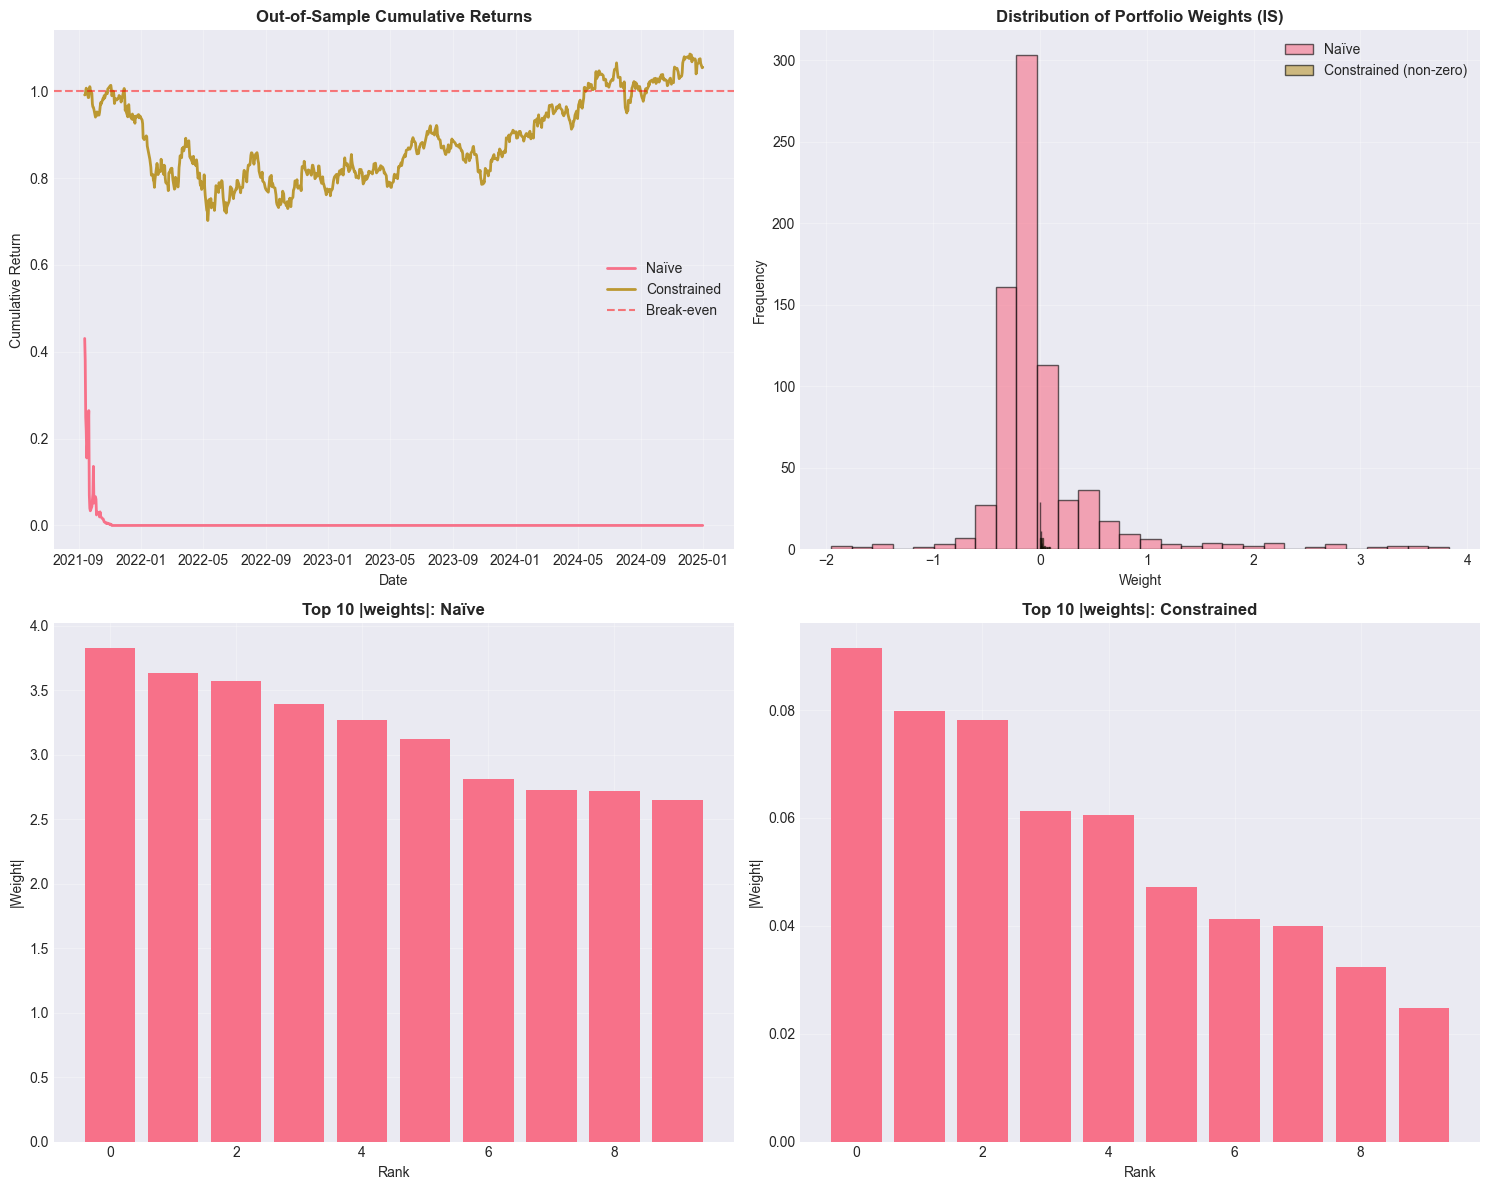

In [17]:
# Visualize portfolio performance (naïve vs constrained)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Cumulative returns (OOS)
if portfolio_returns_oos_naive is not None:
    cum_naive = (1 + portfolio_returns_oos_naive.fillna(0)).cumprod()
    axes[0, 0].plot(cum_naive.index, cum_naive.values, linewidth=2, label='Naïve')
cum_constr = (1 + portfolio_returns_oos.fillna(0)).cumprod()
axes[0, 0].plot(cum_constr.index, cum_constr.values, linewidth=2, label='Constrained')
axes[0, 0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Break-even')
axes[0, 0].set_title('Out-of-Sample Cumulative Returns', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Weight distributions
w_naive = pd.Series(weights_naive, index=is_returns.columns)
w_constr = pd.Series(weights_mv, index=is_returns.columns)

axes[0, 1].hist(w_naive.dropna().values, bins=30, edgecolor='black', alpha=0.6, label='Naïve')
axes[0, 1].hist(w_constr[w_constr > 1e-6].values, bins=30, edgecolor='black', alpha=0.6, label='Constrained (non-zero)')
axes[0, 1].set_title('Distribution of Portfolio Weights (IS)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Weight')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Concentration: top |weights|
topk = 10
top_naive = w_naive.abs().sort_values(ascending=False).head(topk)
top_constr = w_constr.abs().sort_values(ascending=False).head(topk)

axes[1, 0].bar(range(topk), top_naive.values)
axes[1, 0].set_title(f'Top {topk} |weights|: Naïve', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rank')
axes[1, 0].set_ylabel('|Weight|')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(range(topk), top_constr.values)
axes[1, 1].set_title(f'Top {topk} |weights|: Constrained', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Rank')
axes[1, 1].set_ylabel('|Weight|')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Phase 5: What constraints really do

Interpret constraints in three distinct roles:

1. **Numerical stabilization**: prevent the optimizer from chasing tiny eigen-directions of $\Sigma$.
2. **Statistical regularization**: reduce sensitivity to estimation error (often improves OOS even if constraints feel arbitrary).
3. **Economic / regulatory realism**: align the portfolio with implementability (leverage limits, long-only mandates, etc.).

In the baseline comparison above, the *main benefit* of constraints is typically (1) and (2), not (3).


## GIGO mitigation: regularize inputs (shrinkage) and outputs (constraints)

We usually see the same pattern:

- **Garbage in** (noisy means / unstable covariances) + **powerful optimizer** ⇒ extreme, fragile portfolios.
- You can mitigate this in **two complementary places**:
  1. **Inputs**: shrink $\hat\mu$ and $\hat\Sigma$ toward more conservative targets.
  2. **Outputs**: constrain weights so the optimizer cannot “chase noise”.

Below is a simple 2×2 comparison (same assets, same IS/OOS split):

| | **No constraints** | **Constraints** |
|---|---:|---:|
| **Raw inputs** | (A) | (B) |
| **Shrinked inputs** | (C) | (D) |

Focus on **weight stability / concentration** and **IS→OOS Sharpe degradation**.


/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:79: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(returns_array_filled[:, i])
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:79: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(returns_array_filled[:, i])


,IS Sharpe,OOS Sharpe,Sharpe degradation (OOS-IS),W: max|w|,W: top5 |w| sum,W: effective N (1/Σw²),W: gross exposure Σ|w|
A raw + no constraints,4.9161,-0.0818,-4.9979,3.8302,17.6931,0.0042,236.4129
B raw + constraints,2.1069,0.1544,-1.9525,0.0500,0.2500,34.9308,1.0000
C shrinked + no constraints,4.3622,-0.2051,-4.5673,3.5339,13.5097,0.0085,155.7083
D shrinked + constraints,1.7383,0.2291,-1.5092,0.0500,0.2500,21.7252,1.0000


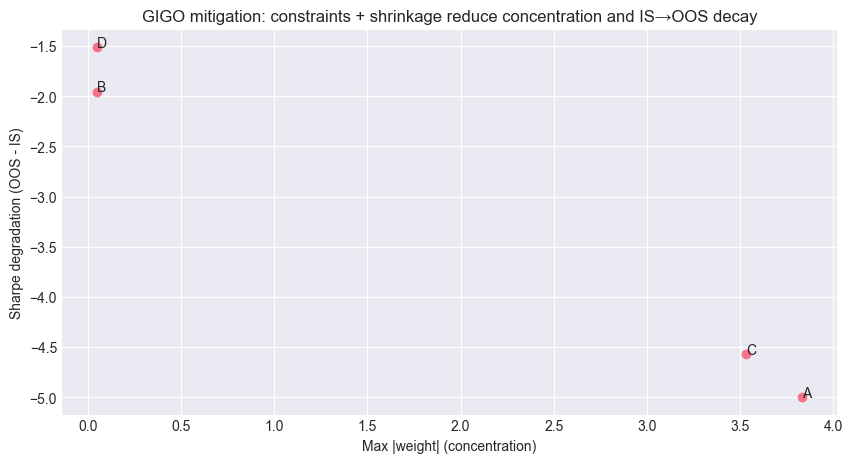

In [18]:
# 2x2: (raw vs shrinked inputs) x (unconstrained vs constrained)

def weight_diagnostics(w):
    w = np.asarray(w).astype(float)
    s = np.sum(w)
    if abs(s) > 1e-12:
        w_norm = w / s
    else:
        w_norm = w.copy()

    l2 = np.sqrt(np.sum(w_norm**2))
    eff_n = 1.0 / np.sum(w_norm**2) if np.sum(w_norm**2) > 0 else np.nan
    top5 = np.sort(np.abs(w_norm))[-5:].sum() if len(w_norm) >= 5 else np.sum(np.abs(w_norm))
    maxw = np.max(np.abs(w_norm)) if len(w_norm) else np.nan
    gross = np.sum(np.abs(w_norm))
    return {
        "max|w|": maxw,
        "top5 |w| sum": top5,
        "effective N (1/Σw²)": eff_n,
        "gross exposure Σ|w|": gross,
        "L2 norm": l2
    }

# Output regularization (constraints): keep it deliberately simple and interpretable
constraints_none = None
constraints_simple = {
    "long_only": True,
    "max_weight": 0.05,   # cap concentration
}

# Input regularization (shrinkage): conservative means + more stable covariance
# - shrink means toward 0 (alpha=0.8 means 80% target, 20% sample)
# - shrink covariance via Ledoit–Wolf
raw_inputs = dict(method="sample", shrinkage=None, mean_shrinkage=None)
shrinked_inputs = dict(method="sample", shrinkage="ledoit-wolf",
                      mean_shrinkage="ridge", mean_shrink_alpha=0.8, mean_shrink_target="zero")

scenarios = {
    "A raw + no constraints": (raw_inputs, constraints_none),
    "B raw + constraints": (raw_inputs, constraints_simple),
    "C shrinked + no constraints": (shrinked_inputs, constraints_none),
    "D shrinked + constraints": (shrinked_inputs, constraints_simple),
}

gigo_results = {}

for name, (inp, cons) in scenarios.items():
    mu_hat, Sig_hat = compute_moments(is_returns, **inp)

    w, is_ret, is_vol, is_sh = optimize_portfolio(
        mu_hat, Sig_hat,
        risk_free_rate=0.02,
        objective="mean_variance",
        risk_aversion=2.0,
        constraints=cons,
        verbose=False
    )

    # Align to OOS universe and renormalize (fully invested)
    # CRITICAL FIX: Use oos_returns_aligned.columns to ensure perfect alignment
    w_series = pd.Series(w, index=is_returns.columns)
    w_oos = w_series.reindex(oos_returns_aligned.columns).fillna(0.0).to_numpy()
    if abs(w_oos.sum()) > 1e-12:
        w_oos = w_oos / w_oos.sum()

    oos_stats, _ = evaluate_portfolio(w_oos, oos_returns_aligned, risk_free_rate=0.02)

    gigo_results[name] = {
        "IS Sharpe": is_sh,
        "OOS Sharpe": oos_stats["sharpe_ratio"],
        "Sharpe degradation (OOS-IS)": oos_stats["sharpe_ratio"] - is_sh,
        **{f"W: {k}": v for k, v in weight_diagnostics(w_oos).items()}
    }

gigo_table = pd.DataFrame(gigo_results).T
display(gigo_table[[
    "IS Sharpe", "OOS Sharpe", "Sharpe degradation (OOS-IS)",
    "W: max|w|", "W: top5 |w| sum", "W: effective N (1/Σw²)", "W: gross exposure Σ|w|"
]].round(4))

# Visual: Sharpe degradation vs concentration
plt.figure(figsize=(10, 5))
plt.scatter(gigo_table["W: max|w|"], gigo_table["Sharpe degradation (OOS-IS)"])
for idx in gigo_table.index:
    plt.annotate(idx.split()[0], (gigo_table.loc[idx, "W: max|w|"], gigo_table.loc[idx, "Sharpe degradation (OOS-IS)"]))
plt.xlabel("Max |weight| (concentration)")
plt.ylabel("Sharpe degradation (OOS - IS)")
plt.title("GIGO mitigation: constraints + shrinkage reduce concentration and IS→OOS decay")
plt.show()


## Example 2: Comparing Different Objectives

Let's compare different optimization objectives to see how they perform:
1. Mean-Variance
2. Maximum Sharpe Ratio
3. Minimum Variance
4. Maximum Return (with volatility constraint)

In [19]:
# Compare different optimization objectives
objectives_to_test = [
    ('mean_variance', {'risk_aversion': 2.0}),
    ('max_sharpe', {}),
    ('min_variance', {'target_return': None}),
    ('max_return', {'target_vol': 0.15})  # Max return with 15% volatility constraint
]

results_comparison = {}

for obj_name, obj_params in objectives_to_test:
    print("\n" + "=" * 60)
    print(f"Optimizing: {obj_name.upper().replace('_', ' ')}")
    print("=" * 60)
    
    # Optimize on IS
    weights, is_ret, is_vol, is_sharpe = optimize_portfolio(
        mu_sample,
        Sigma_sample,
        risk_free_rate=0.02,
        objective=obj_name,
        constraints=constraints_mv,
        verbose=False,
        **obj_params
    )
    
    # Evaluate on OOS
    weights_aligned = pd.Series(weights, index=is_returns.columns)
    # CRITICAL FIX: Extract weights in the same order as oos_returns_aligned.columns
    # This ensures proper alignment between weights and returns columns
    weights_oos = weights_aligned.reindex(oos_returns_aligned.columns).fillna(0.0).values
    weights_oos = weights_oos / weights_oos.sum()
    
    oos_results, _ = evaluate_portfolio(weights_oos, oos_returns_aligned, risk_free_rate=0.02)
    
    results_comparison[obj_name] = {
        'IS': {
            'return': is_ret,
            'volatility': is_vol,
            'sharpe': is_sharpe
        },
        'OOS': {
            'return': oos_results['annual_return'],
            'volatility': oos_results['annual_vol'],
            'sharpe': oos_results['sharpe_ratio']
        },
        'weights': weights
    }
    
    print(f"IS: Return={is_ret:.4f}, Vol={is_vol:.4f}, Sharpe={is_sharpe:.4f}")
    print(f"OOS: Return={oos_results['annual_return']:.4f}, Vol={oos_results['annual_vol']:.4f}, Sharpe={oos_results['sharpe_ratio']:.4f}")


Optimizing: MEAN VARIANCE
IS: Return=0.8026, Vol=0.3795, Sharpe=2.0624
OOS: Return=0.0354, Vol=0.1961, Sharpe=0.0785

Optimizing: MAX SHARPE
IS: Return=0.5341, Vol=0.2301, Sharpe=2.2340
OOS: Return=0.0391, Vol=0.1383, Sharpe=0.1378

Optimizing: MIN VARIANCE
IS: Return=0.1807, Vol=0.1390, Sharpe=1.1562
OOS: Return=0.0458, Vol=0.0809, Sharpe=0.3188

Optimizing: MAX RETURN
IS: Return=0.2947, Vol=0.1500, Sharpe=1.8315
OOS: Return=0.0445, Vol=0.0934, Sharpe=0.2626


In [20]:
# Create comparison table
comparison_table = pd.DataFrame({
    obj_name: {
        'IS Return': results_comparison[obj_name]['IS']['return'],
        'IS Volatility': results_comparison[obj_name]['IS']['volatility'],
        'IS Sharpe': results_comparison[obj_name]['IS']['sharpe'],
        'OOS Return': results_comparison[obj_name]['OOS']['return'],
        'OOS Volatility': results_comparison[obj_name]['OOS']['volatility'],
        'OOS Sharpe': results_comparison[obj_name]['OOS']['sharpe'],
        'Return Degradation': results_comparison[obj_name]['OOS']['return'] - results_comparison[obj_name]['IS']['return'],
        'Sharpe Degradation': results_comparison[obj_name]['OOS']['sharpe'] - results_comparison[obj_name]['IS']['sharpe']
    }
    for obj_name in results_comparison.keys()
})

comparison_table = comparison_table.T
comparison_table.index = [name.replace('_', ' ').title() for name in comparison_table.index]

print("\n" + "=" * 80)
print("Comparison of Different Optimization Objectives")
print("=" * 80)
print(comparison_table.round(4))


Comparison of Different Optimization Objectives
               IS Return  IS Volatility  IS Sharpe  OOS Return  \
Mean Variance     0.8026         0.3795     2.0624      0.0354   
Max Sharpe        0.5341         0.2301     2.2340      0.0391   
Min Variance      0.1807         0.1390     1.1562      0.0458   
Max Return        0.2947         0.1500     1.8315      0.0445   

               OOS Volatility  OOS Sharpe  Return Degradation  \
Mean Variance          0.1961      0.0785             -0.7673   
Max Sharpe             0.1383      0.1378             -0.4950   
Min Variance           0.0809      0.3188             -0.1350   
Max Return             0.0934      0.2626             -0.2502   

               Sharpe Degradation  
Mean Variance             -1.9839  
Max Sharpe                -2.0962  
Min Variance              -0.8374  
Max Return                -1.5688  


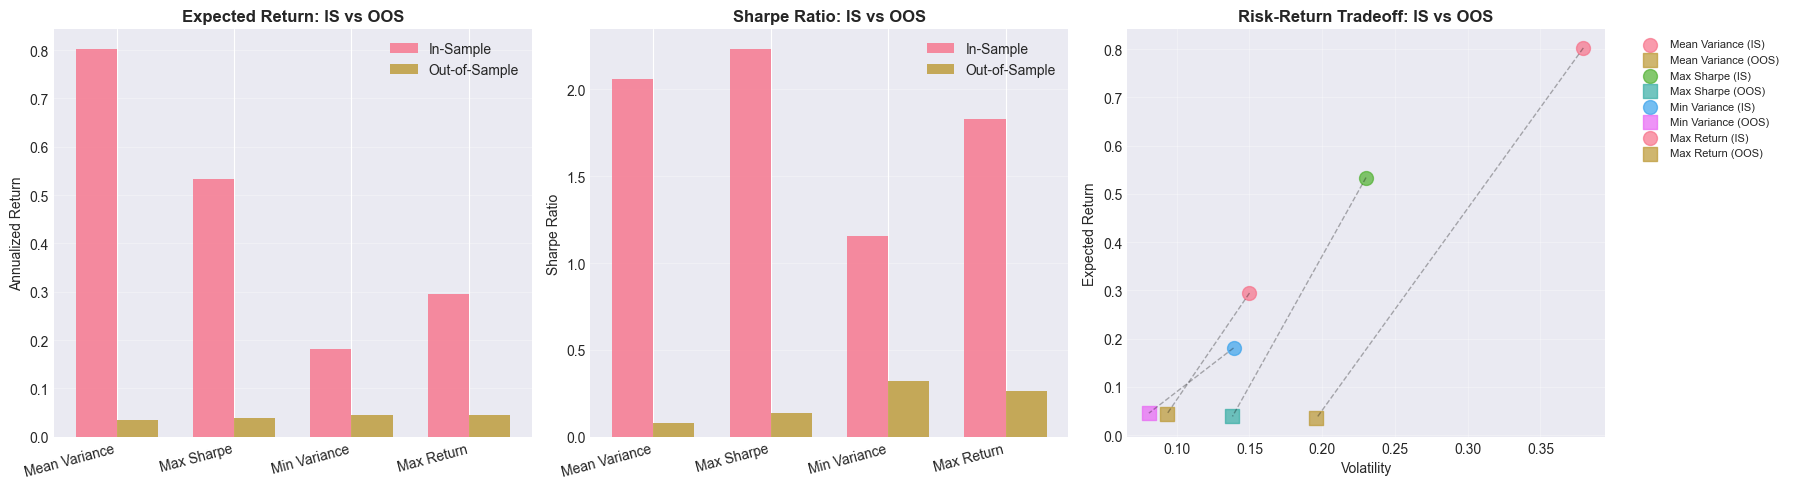

In [21]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Return comparison
is_returns_plot = [results_comparison[obj]['IS']['return'] for obj in results_comparison.keys()]
oos_returns_plot = [results_comparison[obj]['OOS']['return'] for obj in results_comparison.keys()]
obj_names = [name.replace('_', ' ').title() for name in results_comparison.keys()]

x = np.arange(len(obj_names))
width = 0.35
axes[0].bar(x - width/2, is_returns_plot, width, label='In-Sample', alpha=0.8)
axes[0].bar(x + width/2, oos_returns_plot, width, label='Out-of-Sample', alpha=0.8)
axes[0].set_title('Expected Return: IS vs OOS', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Annualized Return')
axes[0].set_xticks(x)
axes[0].set_xticklabels(obj_names, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Sharpe ratio comparison
is_sharpe_plot = [results_comparison[obj]['IS']['sharpe'] for obj in results_comparison.keys()]
oos_sharpe_plot = [results_comparison[obj]['OOS']['sharpe'] for obj in results_comparison.keys()]

axes[1].bar(x - width/2, is_sharpe_plot, width, label='In-Sample', alpha=0.8)
axes[1].bar(x + width/2, oos_sharpe_plot, width, label='Out-of-Sample', alpha=0.8)
axes[1].set_title('Sharpe Ratio: IS vs OOS', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_xticks(x)
axes[1].set_xticklabels(obj_names, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Risk-Return scatter
for obj_name in results_comparison.keys():
    is_ret = results_comparison[obj_name]['IS']['return']
    is_vol = results_comparison[obj_name]['IS']['volatility']
    oos_ret = results_comparison[obj_name]['OOS']['return']
    oos_vol = results_comparison[obj_name]['OOS']['volatility']
    
    label = obj_name.replace('_', ' ').title()
    axes[2].scatter(is_vol, is_ret, s=100, alpha=0.7, marker='o', label=f'{label} (IS)')
    axes[2].scatter(oos_vol, oos_ret, s=100, alpha=0.7, marker='s', label=f'{label} (OOS)')
    axes[2].plot([is_vol, oos_vol], [is_ret, oos_ret], 'k--', alpha=0.3, linewidth=1)

axes[2].set_title('Risk-Return Tradeoff: IS vs OOS', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Volatility')
axes[2].set_ylabel('Expected Return')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Example 3: Input regularization (shrinkage of means and covariances)

GIGO is not just about covariances. In practice:

- $\hat\mu$ is extremely noisy (especially at short horizons).
- $\hat\Sigma$ can be ill-conditioned and unstable.

Below we compare four input choices (still using the **same output constraint set** for fairness):

1. **None**: sample mean + sample covariance  
2. **Cov shrink only**: sample mean + Ledoit–Wolf covariance  
3. **Mean shrink only**: shrink sample mean toward 0  
4. **Both**: mean shrink + Ledoit–Wolf covariance

Interpretation goal: **input shrinkage should reduce optimizer aggressiveness and improve OOS stability**, even before we touch the constraint set.


/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:79: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(returns_array_filled[:, i])
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:38: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(returns_array, axis=0)
/var/folders/1g/3hly6g694k12jhfx7g3xkkj40000gq/T/ipykernel_43293/2012660356.py:79: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(returns_array_filled[:, i])


,IS Sharpe,OOS Sharpe,Sharpe degradation (OOS-IS),W: max|w|,W: top5 |w| sum,W: effective N (1/Σw²)
"None (sample μ, sample Σ)",2.1069,0.1544,-1.9525,0.0500,0.2500,34.9308
"Cov shrink (sample μ, LW Σ)",5.6661,0.1979,-5.4681,0.0500,0.2500,21.0521
"Mean shrink (μ→0, sample Σ)",0.3218,0.2151,-0.1067,0.0227,0.1026,161.1777
"Both (μ→0, LW Σ)",1.7383,0.2291,-1.5092,0.0500,0.2500,21.7252


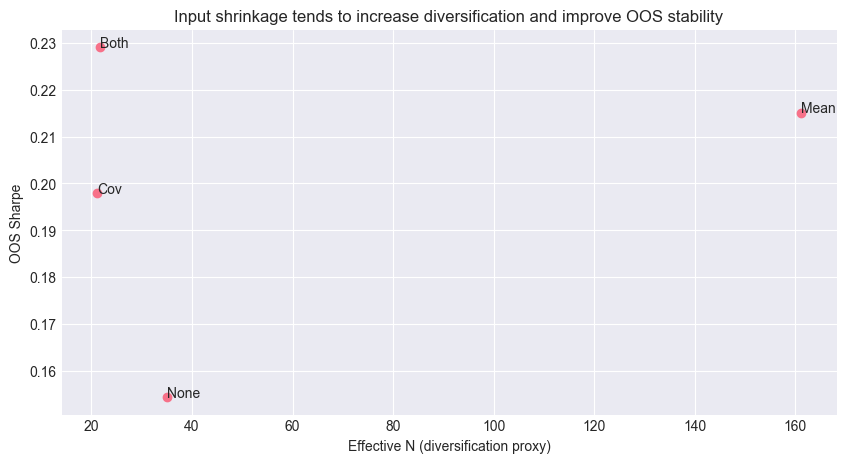

In [22]:
# Compare mean/covariance shrinkage options (inputs), holding output constraints fixed

input_specs = {
    "None (sample μ, sample Σ)": dict(method="sample", shrinkage=None, mean_shrinkage=None),
    "Cov shrink (sample μ, LW Σ)": dict(method="sample", shrinkage="ledoit-wolf", mean_shrinkage=None),
    "Mean shrink (μ→0, sample Σ)": dict(method="sample", shrinkage=None,
                                        mean_shrinkage="ridge", mean_shrink_alpha=0.8, mean_shrink_target="zero"),
    "Both (μ→0, LW Σ)": dict(method="sample", shrinkage="ledoit-wolf",
                             mean_shrinkage="ridge", mean_shrink_alpha=0.8, mean_shrink_target="zero"),
}

# Use a single, transparent constraint set so the comparison is about *inputs*
constraints_for_inputs = constraints_simple  # long-only + max weight cap (defined above)

shrinkage_results = {}

for label, spec in input_specs.items():
    mu_hat, Sig_hat = compute_moments(is_returns, **spec)

    w, is_ret, is_vol, is_sh = optimize_portfolio(
        mu_hat, Sig_hat,
        risk_free_rate=0.02,
        objective="mean_variance",
        risk_aversion=2.0,
        constraints=constraints_for_inputs,
        verbose=False
    )

    w_series = pd.Series(w, index=is_returns.columns)
    # CRITICAL FIX: Use oos_returns_aligned.columns to ensure perfect alignment
    w_oos = w_series.reindex(oos_returns_aligned.columns).fillna(0.0).to_numpy()
    if abs(w_oos.sum()) > 1e-12:
        w_oos = w_oos / w_oos.sum()

    oos_stats, _ = evaluate_portfolio(w_oos, oos_returns_aligned, risk_free_rate=0.02)

    shrinkage_results[label] = {
        "IS Sharpe": is_sh,
        "OOS Sharpe": oos_stats["sharpe_ratio"],
        "Sharpe degradation (OOS-IS)": oos_stats["sharpe_ratio"] - is_sh,
        **{f"W: {k}": v for k, v in weight_diagnostics(w_oos).items()},
    }

inputs_table = pd.DataFrame(shrinkage_results).T

display(inputs_table[[
    "IS Sharpe", "OOS Sharpe", "Sharpe degradation (OOS-IS)",
    "W: max|w|", "W: top5 |w| sum", "W: effective N (1/Σw²)"
]].round(4))

plt.figure(figsize=(10, 5))
plt.scatter(inputs_table["W: effective N (1/Σw²)"], inputs_table["OOS Sharpe"])
for idx in inputs_table.index:
    plt.annotate(idx.split()[0], (inputs_table.loc[idx, "W: effective N (1/Σw²)"], inputs_table.loc[idx, "OOS Sharpe"]))
plt.xlabel("Effective N (diversification proxy)")
plt.ylabel("OOS Sharpe")
plt.title("Input shrinkage tends to increase diversification and improve OOS stability")
plt.show()


## Key Takeaways

1. **Look-ahead bias**: Split data **before** estimating $\mu$ and $\Sigma$. Never let OOS data leak into inputs.

2. **IS vs OOS is the reality check**: Strong IS performance is cheap. The question is whether it survives OOS.

3. **GIGO is amplified by optimization**: Estimation error in $\mu$ and $\Sigma$ is not “averaged out” — the optimizer can concentrate it into extreme weights.

4. **Constraints are more than “realism”**:
   - They stabilize numerics,
   - regularize statistics,
   - and only then reflect trading/regulatory rules.

5. **What we intentionally simplified today** 
   - No transaction costs / turnover penalties,
   - no walk-forward re-optimization,
   - simple sample estimates (plus optional shrinkage experiments).

**Meta-lesson:** Portfolio optimization is a fragile mapping from beliefs to allocations. The main skill is not solving the convex program — it is designing inputs, constraints, and evaluation so the output is robust.
